In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Customer Segmentation Project: RFM Analysis

## 1. Project Overview

This project applies customer segmentation techniques using Recency, Frequency, and Monetary (RFM) analysis to better understand purchasing behaviour and customer value.

The objective is to identify meaningful customer segments based on transaction history and to translate these findings into actionable business insights that can support retention, marketing, and customer relationship strategies.

This project demonstrates foundational data analysis and segmentation skills, including feature engineering, scoring, clustering, and business interpretation, and reflects my preparation for further study in Data Science and AI.

## 2. Problem Statement

Businesses often have large amounts of customer transaction data, but without structured analysis it can be difficult to identify which customers are most valuable, which are at risk of disengaging, and which groups require different strategies.

The aim of this project is to segment customers using RFM analysis in order to answer key questions, including:

- Which customers are the most valuable?
- Which customers are less engaged or at risk of churning?
- How can customer groups be identified and targeted more effectively?

By addressing these questions, the project demonstrates how customer segmentation can support data-driven business decision-making.

## 3. Dataset Overview

The dataset used in this project contains customer transaction data, including purchase timing, order frequency, and spending behaviour.

The analysis focuses on variables required for RFM segmentation:

- **Recency** – how recently a customer made a purchase
- **Frequency** – how often a customer makes purchases
- **Monetary** – how much a customer spends

These variables are used to evaluate customer value and identify distinct customer segments.

## 4. Data Cleaning

The dataset was prepared by loading the relevant tables and combining them to create a customer-level transactional dataset suitable for RFM analysis. Data types were reviewed and the purchase timestamp was converted into a datetime format.

In [2]:
orders = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv")

In [3]:
customers = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv")

items = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv")

In [4]:
orders_customers = orders.merge(customers, on="customer_id")

rfm_data = orders_customers.merge(items, on="order_id")


In [5]:
rfm_data["order_purchase_timestamp"] = pd.to_datetime(rfm_data["order_purchase_timestamp"])


## 5. Feature Engineering (RFM Creation)

In this section, customer-level RFM (Recency, Frequency, Monetary) features were created from the transactional dataset to summarise customer behaviour.

In [6]:
latest_date = rfm_data["order_purchase_timestamp"].max()

rfm = rfm_data.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (latest_date - x.max()).days,
    "order_id": "count",
    "price": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90
0000f46a3911fa3c0805444483337064,541,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99
0004aac84e0df4da2b147fca70cf8255,292,1,180.00


The resulting RFM table provides a customer-level summary of purchasing behaviour and forms the basis for customer segmentation.

## 6. RFM Analysis

The following visualisations and summary statistics help explore relationships between purchase frequency, spending behaviour, and customer value.

RFM analysis was used to evaluate customer value based on three dimensions:

- **Recency** – how recently a customer made a purchase  
- **Frequency** – how often a customer makes purchases  
- **Monetary** – how much a customer spends  

These metrics help identify which customers are highly engaged, which are less active, and which may require different retention strategies.

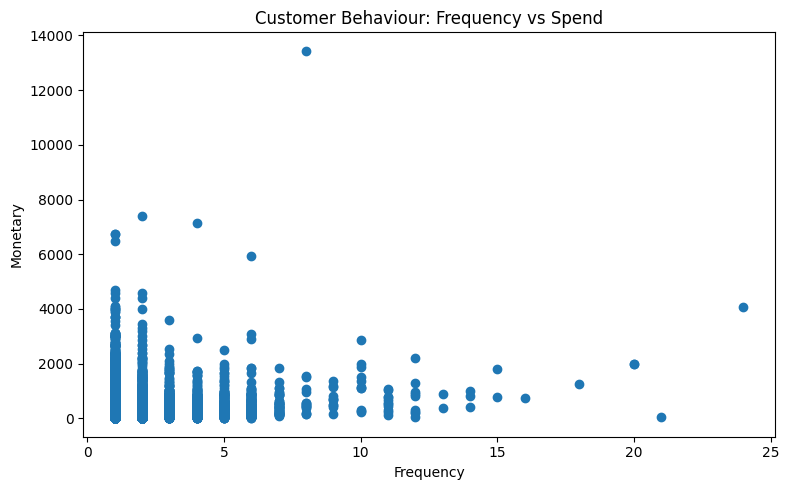

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(rfm["Frequency"], rfm["Monetary"])

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Behaviour: Frequency vs Spend")

plt.tight_layout()
plt.show()

**Insight:** Customers with higher purchase frequency tend to spend more overall, although there is variation across the dataset. This suggests that increasing customer engagement and repeat purchases could contribute to higher revenue.

This summary provides an overview of the distribution of Recency, Frequency, and Monetary values across customers.

In [8]:
rfm.describe()


,Recency,Frequency,Monetary
count,95420.000000,95420.00000,95420.000000
mean,242.600377,1.18057,142.440198
std,153.160320,0.62145,217.656355
min,0.000000,1.00000,0.850000
25%,118.000000,1.00000,47.900000
50%,223.000000,1.00000,89.900000
75%,352.000000,1.00000,155.000000
max,728.000000,24.00000,13440.000000


This summary provides an overview of the distribution of Recency, Frequency, and Monetary values across customers.

## 7. Customer Segmentation

Customers were segmented based on their purchasing behaviour using simple rule-based criteria derived from RFM values.

- Customers with high spending were classified as **High Value**
- Customers with only one purchase were classified as **One-time**
- Remaining customers were classified as **Regular**

In [9]:
rfm["Segment"] = "Regular"

rfm.loc[rfm["Monetary"] > rfm["Monetary"].quantile(0.75), "Segment"] = "High Value"
rfm.loc[rfm["Frequency"] == 1, "Segment"] = "One-time"

rfm.head()


,Recency,Frequency,Monetary,Segment
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,One-time
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,One-time
0000f46a3911fa3c0805444483337064,541,1,69.00,One-time
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,One-time
0004aac84e0df4da2b147fca70cf8255,292,1,180.00,One-time


In [10]:
rfm["Segment"].value_counts()


Segment
One-time      83551
Regular        6283
High Value     5586
Name: count, dtype: int64

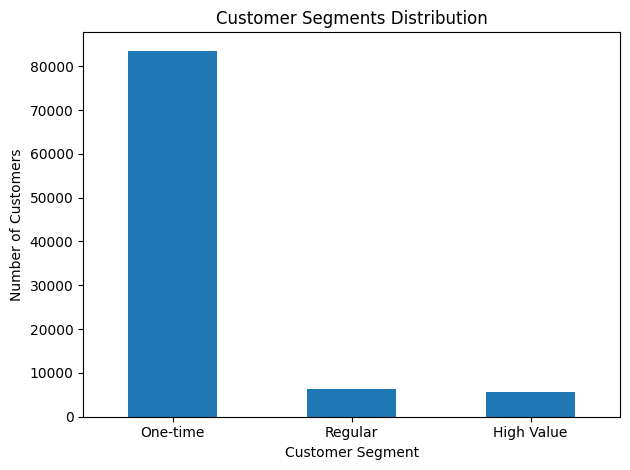

In [11]:
rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The segmentation shows that the majority of customers are one-time buyers, while a smaller group represents high-value customers contributing more significantly to revenue.

In [12]:
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
High Value,233.583602,2.675439,366.364801
One-time,243.073727,1.000000,131.539829
Regular,244.322298,2.252746,88.309040


This table highlights the behavioural differences between customer segments.

High-value customers tend to purchase more frequently and spend significantly more, while one-time customers show low engagement with only a single purchase. Regular customers fall between these groups, with moderate purchase frequency but lower overall spending.

## 8. Advanced Analysis: Customer Clustering (K-Means)

To further enhance the analysis, K-means clustering was applied to identify natural groupings of customers based on their Recency, Frequency, and Monetary values.

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


X = rfm[["Recency", "Frequency", "Monetary"]]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)


rfm[["Recency", "Frequency", "Monetary", "Cluster"]].head()

,Recency,Frequency,Monetary,Cluster
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,1
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,1
0000f46a3911fa3c0805444483337064,541,1,69.00,0
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,0
0004aac84e0df4da2b147fca70cf8255,292,1,180.00,0


In [14]:
rfm["Cluster"].value_counts()

Cluster
1    52108
0    38379
2     2808
3     2125
Name: count, dtype: int64

The following visualisations illustrate the distribution and behavioural patterns of the identified customer clusters.

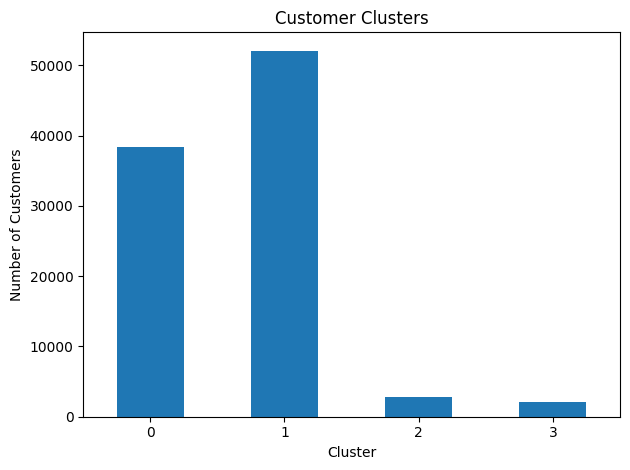

In [15]:
rfm["Cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

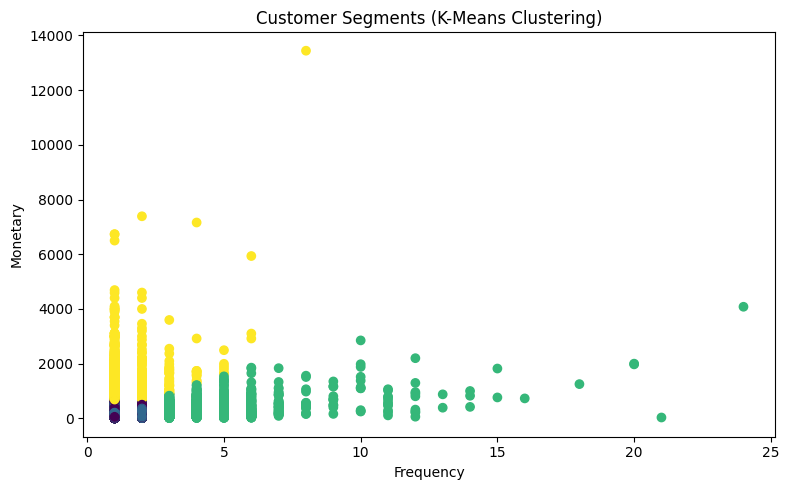

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments (K-Means Clustering)")

plt.tight_layout()
plt.show()

**Insight:** K-means clustering reveals natural groupings of customers based on purchasing behaviour, identifying distinct segments beyond predefined rules. This highlights the diversity of customer profiles and supports more targeted and effective business strategies.

## 9. Key Insights

- The majority of customers are one-time buyers, indicating low repeat purchase behaviour and potential challenges in customer retention  

- A small group of high-value customers contributes disproportionately to overall revenue, highlighting the importance of identifying and retaining these customers  

- Frequency is generally low across the dataset, suggesting that most customers do not make repeated purchases  

- There is significant variation in monetary value, indicating differences in customer spending behaviour  

- RFM analysis effectively highlights differences in customer engagement and value, providing a foundation for targeted marketing strategies  

## 10. Business Recommendations

- Focus on retaining high-value customers through personalised offers, loyalty programmes, and exclusive incentives  

- Develop targeted marketing campaigns to encourage repeat purchases among one-time buyers  

- Implement customer segmentation strategies to tailor communication and promotions based on customer behaviour  

- Increase customer engagement through email marketing, promotions, and personalised product recommendations  

- Use data-driven insights to optimise marketing spend and improve overall customer lifetime value  

## 11. Limitations and Future Work

This analysis is limited to historical transactional data and does not include predictive modelling or real-time customer behaviour.

Future work could extend this project by applying machine learning techniques such as clustering optimisation, customer lifetime value prediction, and personalised recommendation systems to further enhance customer segmentation and business decision-making.